# 04 XGBoost Base

**Iteración:** 2 Primer modelo no lineal

## Objetivo

Entrenar un modelo **XGBoost** (Extreme Gradient Boosting) con las mismas features básicas que se utilizaron en la iteración anterior con Ridge, sin feature engineering adicional. El propósito es aislar el **aporte del cambio de algoritmo**, manteniendo el resto de variables constantes.

## Justificación del algoritmo

XGBoost es el estándar de facto para datos tabulares y resuelve directamente las limitaciones detectadas en la iteración 1:

1. **Trata variables categóricas codificadas como enteros sin asumir orden ni magnitud**.
2. **Captura interacciones entre features** de forma nativa.
3. **Modela relaciones no lineales** mediante árboles de decisión.
4. **Robusto a la escala de las variables**, no requiere normalización previa.

## Configuración

Hiperparámetros por defecto de XGBoost.

In [7]:
!pip install seaborn
# conda sí tiene XGBoost precompilado para el entorno
!conda install -y -c conda-forge xgboost

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/ec2-user/anaconda3/envs/python3

  added / updated specs:
    - xgboost


The following packages will be DOWNGRADED:

  numpy                               2.4.3-py312h33ff503_0 --> 2.2.6-py312h72c5963_0 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import BytesIO
import time
import os

import xgboost as xgb

# Configuración
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)

print(f"Imports cargados | XGBoost {xgb.__version__}")

Imports cargados | XGBoost 3.2.0


In [9]:
# Carga de datos desde S3
BUCKET_NAME = "prediccion-demanda-processed-319501512128"
PREFIX_SPLITS = "rossmann/splits/"
TIMESTAMP = "20260410_054619"

s3_client = boto3.client("s3")

def load_csv_from_s3(bucket, key):
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(BytesIO(response["Body"].read()))

print("Cargando splits...")
df_train = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}train_{TIMESTAMP}.csv")
df_val = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}validation_{TIMESTAMP}.csv")
df_test = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}test_{TIMESTAMP}.csv")

for df in [df_train, df_val, df_test]:
    df["Date"] = pd.to_datetime(df["Date"])

print(f"Train: {df_train.shape}")
print(f"Val:   {df_val.shape}")
print(f"Test:  {df_test.shape}")

# Métricas
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def evaluate(y_true, y_pred, label=""):
    metrics = {
        "RMSPE": rmspe(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
    }
    if label:
        print(f"{label}")
    print(f"   RMSPE: {metrics['RMSPE']:.4f}  ({metrics['RMSPE']*100:.2f}%)")
    print(f"   RMSE:  {metrics['RMSE']:.2f} €")
    print(f"   MAE:   {metrics['MAE']:.2f} €")
    return metrics

Cargando splits...
Train: (591036, 20)
Val:   (126651, 20)
Test:  (126651, 20)


In [10]:
# Selección de features (mismas que Ridge)
TARGET = "Sales"
EXCLUDE = ["Sales", "Customers", "Date"]
FEATURES = [c for c in df_train.columns if c not in EXCLUDE]

print(f"Target: {TARGET}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values
X_val = df_val[FEATURES].values
y_val = df_val[TARGET].values
X_test = df_test[FEATURES].values
y_test = df_test[TARGET].values

print(f"\nX_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")

Target: Sales
Features (17): ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Week', 'DayOfYear']

X_train: (591036, 17)  |  y_train: (591036,)
X_val:   (126651, 17)  |  y_val:   (126651,)


In [12]:
# Entrenamiento de XGBoost
print("Entrenando XGBoost...")
t0 = time.time()

model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20,
)

train_time = time.time() - t0
print(f"\nModelo entrenado en {train_time:.2f} segundos")

print("\nHiperparámetros principales:")
print(f"  n_estimators:  {model_xgb.n_estimators}")
print(f"  max_depth:     {model_xgb.max_depth}")
print(f"  learning_rate: {model_xgb.learning_rate}")
print(f"  tree_method:   {model_xgb.tree_method}")

Entrenando XGBoost...
[0]	validation_0-rmse:2981.65080	validation_1-rmse:3126.37545
[20]	validation_0-rmse:2399.91822	validation_1-rmse:2578.01931
[40]	validation_0-rmse:2155.87732	validation_1-rmse:2356.94443
[60]	validation_0-rmse:1976.83594	validation_1-rmse:2198.30497
[80]	validation_0-rmse:1831.03442	validation_1-rmse:2074.95912
[100]	validation_0-rmse:1686.70722	validation_1-rmse:1951.94214
[120]	validation_0-rmse:1586.88496	validation_1-rmse:1866.24930
[140]	validation_0-rmse:1506.96729	validation_1-rmse:1801.58415
[160]	validation_0-rmse:1410.27430	validation_1-rmse:1717.87140
[180]	validation_0-rmse:1351.15742	validation_1-rmse:1668.77653
[199]	validation_0-rmse:1296.31982	validation_1-rmse:1627.51616

Modelo entrenado en 15.44 segundos

Hiperparámetros principales:
  n_estimators:  200
  max_depth:     6
  learning_rate: 0.1
  tree_method:   hist


In [13]:
# Predicciones y métricas
y_pred_val = model_xgb.predict(X_val)
y_pred_val = np.clip(y_pred_val, 0, None)  # nunca negativo

print("=" * 60)
metrics_xgb_val = evaluate(y_val, y_pred_val, label="XGBoost BASE — Validation")
print("=" * 60)

# Comparación con baseline y Ridge
baseline_rmspe = 0.3803
ridge_rmspe = 0.5908

print("\nComparación con iteraciones anteriores:")
print(f"   Baseline RMSPE: {baseline_rmspe:.4f}  ({baseline_rmspe*100:.2f}%)")
print(f"   Ridge RMSPE:    {ridge_rmspe:.4f}  ({ridge_rmspe*100:.2f}%)")
print(f"   XGBoost RMSPE:  {metrics_xgb_val['RMSPE']:.4f}  ({metrics_xgb_val['RMSPE']*100:.2f}%)")

improvement_baseline = (baseline_rmspe - metrics_xgb_val["RMSPE"]) / baseline_rmspe * 100
print(f"\n   Mejora vs baseline: {improvement_baseline:+.1f}%")

XGBoost BASE — Validation
   RMSPE: 0.3716  (37.16%)
   RMSE:  1627.52 €
   MAE:   1139.46 €

Comparación con iteraciones anteriores:
   Baseline RMSPE: 0.3803  (38.03%)
   Ridge RMSPE:    0.5908  (59.08%)
   XGBoost RMSPE:  0.3716  (37.16%)

   Mejora vs baseline: +2.3%


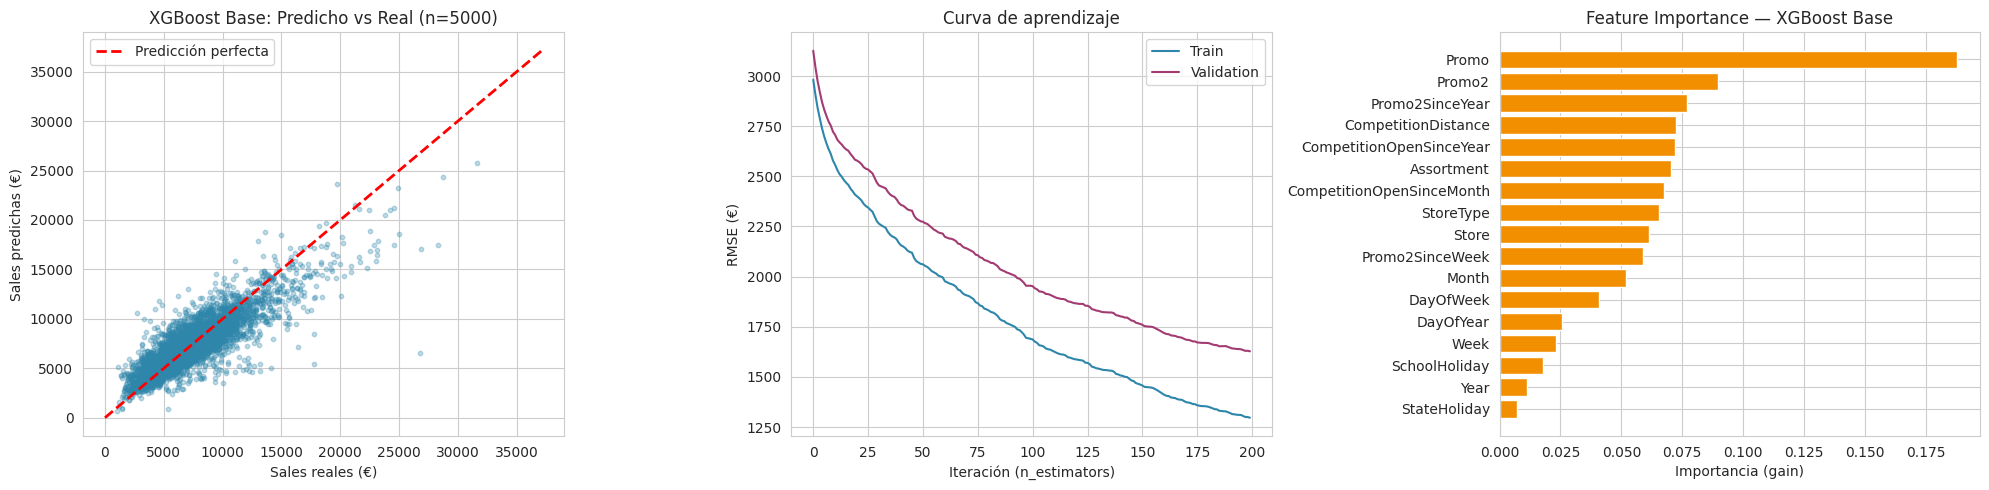


Top 5 features más importantes:
                 Feature  Importance
                   Promo    0.187901
                  Promo2    0.089566
         Promo2SinceYear    0.076955
     CompetitionDistance    0.072263
CompetitionOpenSinceYear    0.071826


In [14]:
# Visualizaciones: predicho vs real + curva de aprendizaje + feature importance
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 Scatter predicho vs real
sample_idx = np.random.choice(len(y_val), 5000, replace=False)
axes[0].scatter(y_val[sample_idx], y_pred_val[sample_idx], alpha=0.3, s=10, color="#2E86AB")
max_val = max(y_val.max(), y_pred_val.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
axes[0].set_xlabel("Sales reales (€)")
axes[0].set_ylabel("Sales predichas (€)")
axes[0].set_title("XGBoost Base: Predicho vs Real (n=5000)")
axes[0].legend()

# 2 Curva de aprendizaje
results = model_xgb.evals_result()
epochs = len(results["validation_0"]["rmse"])
axes[1].plot(range(epochs), results["validation_0"]["rmse"], label="Train", color="#2E86AB")
axes[1].plot(range(epochs), results["validation_1"]["rmse"], label="Validation", color="#A23B72")
axes[1].set_xlabel("Iteración (n_estimators)")
axes[1].set_ylabel("RMSE (€)")
axes[1].set_title("Curva de aprendizaje")
axes[1].legend()

# 3 Feature importance
importance = model_xgb.feature_importances_
fi_df = pd.DataFrame({"Feature": FEATURES, "Importance": importance}).sort_values("Importance", ascending=True)
axes[2].barh(fi_df["Feature"], fi_df["Importance"], color="#F18F01")
axes[2].set_xlabel("Importancia (gain)")
axes[2].set_title("Feature Importance — XGBoost Base")

plt.tight_layout()
plt.savefig("../results/plots/xgboost_base_results.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 5 features más importantes:")
print(fi_df.sort_values("Importance", ascending=False).head().to_string(index=False))

In [15]:
# Guardar métricas en la tabla comparativa
results_path = "../results/metrics_comparison.csv"

new_row = pd.DataFrame([{
    "Iteration": 2,
    "Model": "XGBoost Base (n=200, depth=6, lr=0.1)",
    "Split": "Validation",
    "RMSPE": metrics_xgb_val["RMSPE"],
    "RMSE": metrics_xgb_val["RMSE"],
    "MAE": metrics_xgb_val["MAE"],
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Iteration"] != 2]
    results_df = pd.concat([existing, new_row], ignore_index=True).sort_values("Iteration")
else:
    results_df = new_row

results_df.to_csv(results_path, index=False)

print("Métricas guardadas")
print("\nTabla comparativa actualizada:")
print(results_df.to_string(index=False))

Métricas guardadas

Tabla comparativa actualizada:
 Iteration                                    Model      Split    RMSPE        RMSE         MAE
         0 Baseline Ingenuo (media Store×DayOfWeek) Validation 0.380258 1850.471558 1325.987539
         1             Ridge Regression (alpha=1.0) Validation 0.590811 2917.271294 2100.046361
         2    XGBoost Base (n=200, depth=6, lr=0.1) Validation 0.371589 1627.516162 1139.461390


## Resultados de la iteración 2

XGBoost out-of-the-box, con los mismos features que Ridge, supera ampliamente tanto al baseline como al modelo lineal. El cambio de algoritmo, sin feature engineering adicional, demuestra el **aporte del modelado no lineal y la capacidad nativa de XGBoost para tratar variables categóricas codificadas como enteros**.